In [1]:
# ── CELDA 1: Importaciones para Regresión Logística ───────────────────────────
import sys
import os

# 🔥 Configuración de rutas para encontrar la carpeta 'scripts'
directorio_raiz = os.path.abspath('..')
if directorio_raiz not in sys.path:
    sys.path.insert(0, directorio_raiz)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# Modelo de Regresión Logística y Escalador (Obligatorio para este modelo)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Métricas de Clasificación
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay
)

from sqlalchemy import text
from scripts.database import engine

# Estilo visual consistente con el proyecto económico
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print("✅ Librerías para Regresión Logística importadas")
print(f"   Pandas: {pd.__version__} | Numpy: {np.__version__} | Seaborn: {sns.__version__}")
print("\n⚠️ Nota: La Regresión Logística SÍ requiere StandardScaler para funcionar correctamente.")

✅ Librerías para Regresión Logística importadas
   Pandas: 2.2.2 | Numpy: 1.26.4 | Seaborn: 0.13.2

⚠️ Nota: La Regresión Logística SÍ requiere StandardScaler para funcionar correctamente.


In [5]:
# ── CELDA 2: Extracción SQL y Transformación ──────────────────────────────────
# Usamos la consulta exacta que nos funcionó en el notebook anterior

SQL_QUERY = """
SELECT 
    pais, 
    anio, 
    indicador, 
    valor 
FROM worldbank_registros 
ORDER BY pais, anio;
"""

with engine.connect() as conn:
    df_raw = pd.read_sql(text(SQL_QUERY), conn)

# --- PROCESAMIENTO PARA REGRESIÓN LOGÍSTICA ---
# 1. Pivotar: Convertimos filas de indicadores en columnas
df_economia = df_raw.pivot_table(index=["pais", "anio"], columns="indicador", values="valor").reset_index()

# 2. Renombrar columnas dinámicamente (por si los nombres varían un poco)
rename_map = {}
for col in df_economia.columns:
    c_lower = str(col).lower()
    if "gdp" in c_lower or "pib" in c_lower: rename_map[col] = 'pib'
    elif "population" in c_lower or "poblacion" in c_lower: rename_map[col] = 'poblacion'
    elif "inflation" in c_lower or "inflacion" in c_lower: rename_map[col] = 'inflacion'

df_economia = df_economia.rename(columns=rename_map).copy()

# 3. Relleno inteligente de nulos (Interpolación por país)
for col in ['pib', 'poblacion', 'inflacion']:
    if col in df_economia.columns:
        df_economia[col] = df_economia.groupby('pais')[col].transform(
            lambda x: x.interpolate(method='linear').ffill().bfill()
        )
        # Evitamos ceros o negativos para futuros logaritmos
        df_economia[col] = df_economia[col].clip(lower=0.01)

# 3.1 Limpieza final obligatoria: La Regresión Logística no perdona un solo NaN
columnas_requeridas = [col for col in ['pib', 'poblacion', 'inflacion'] if col in df_economia.columns]
df_economia = df_economia.dropna(subset=columnas_requeridas)

# 4. Creación de la Variable Objetivo: Ingreso Alto (1) vs Bajo (0)
mediana_pib = df_economia['pib'].median()
df_economia['es_ingreso_alto'] = (df_economia['pib'] > mediana_pib).astype(int)

print(f"✅ Datos cargados y listos: {df_economia.shape[0]:,} registros")
print(f"📊 Columnas detectadas: {columnas_requeridas}")
print(f"\nBalance de clases (Frontera: {mediana_pib:,.0f} USD):")
bal = df_economia['es_ingreso_alto'].value_counts()
pct = df_economia['es_ingreso_alto'].value_counts(normalize=True) * 100
print(f"   Ingreso Alto (1): {bal.get(1, 0):,} ({pct.get(1, 0):.1f}%)")
print(f"   Ingreso Bajo (0): {bal.get(0, 0):,} ({pct.get(0, 0):.1f}%)")

df_economia.head()

✅ Datos cargados y listos: 650 registros
📊 Columnas detectadas: ['pib', 'poblacion', 'inflacion']

Balance de clases (Frontera: 59,413,004,061 USD):
   Ingreso Alto (1): 325 (50.0%)
   Ingreso Bajo (0): 325 (50.0%)


indicador,pais,anio,pib,inflacion,poblacion,es_ingreso_alto
0,Argentina,1960,1.586547e+10,34.277224,20386045.0,0
1,Argentina,1961,2.013222e+10,34.277224,20726276.0,0
2,Argentina,1962,1.833769e+10,34.277224,21072538.0,0
3,Argentina,1963,1.827212e+10,34.277224,21421705.0,0
4,Argentina,1964,2.560525e+10,34.277224,21769453.0,0


In [7]:
# ── CELDA 3: Validación y Exploración ────────────────────────────────────────
print("=" * 60)
print(f"{'VALIDACIÓN DEL DATASET ECONÓMICO':^60}")
print("=" * 60)

# 1. Verificación de Tipos y Nulos
print("\n📋 Estado de los datos (Tipos y Nulos):")
analisis_nulos = df_economia.dtypes.to_frame('dtype').join(
    df_economia.isnull().sum().to_frame('nulos')
)
print(analisis_nulos)

# 2. Balance de clases (Crucial para Logística)
# 🔥 Ajustado a 'es_ingreso_alto' para coincidir con la Celda 2
col_objetivo = 'es_ingreso_alto'

balance = df_economia[col_objetivo].value_counts()
pct     = df_economia[col_objetivo].value_counts(normalize=True) * 100

print(f"\n🎯 Balance de la variable objetivo (Ingreso):")
print(f"   Ingreso Alto  (1): {balance.get(1, 0):>6,}  ({pct.get(1, 0):.1f}%)")
print(f"   Ingreso Bajo  (0): {balance.get(0, 0):>6,}  ({pct.get(0, 0):.1f}%)")

# 3. Resumen Estadístico (Detección de escalas y outliers)
print(f"\n📈 Resumen estadístico de indicadores:")
columnas_interes = ['pib', 'poblacion', 'inflacion']
cols_presentes = [c for c in columnas_interes if c in df_economia.columns]
print(df_economia[cols_presentes].describe().round(2))

# 4. Cobertura por País (Top 10)
print(f"\n🌍 Cobertura por País (Top 10):")
print(df_economia['pais'].value_counts().head(10).to_string())

              VALIDACIÓN DEL DATASET ECONÓMICO              

📋 Estado de los datos (Tipos y Nulos):
                   dtype  nulos
indicador                      
pais              object      0
anio               int64      0
pib              float64      0
inflacion        float64      0
poblacion        float64      0
es_ingreso_alto    int64      0

🎯 Balance de la variable objetivo (Ingreso):
   Ingreso Alto  (1):    325  (50.0%)
   Ingreso Bajo  (0):    325  (50.0%)

📈 Resumen estadístico de indicadores:
indicador           pib     poblacion  inflacion
count      6.500000e+02  6.500000e+02     650.00
mean       1.075913e+12  6.843710e+07      59.46
std        3.571895e+12  9.813289e+07     367.50
min        2.888844e+08  1.883514e+06       0.01
25%        1.536590e+10  9.320600e+06       4.19
50%        5.941300e+10  2.437121e+07       9.77
75%        3.177249e+11  7.956271e+07      34.28
max        2.875096e+13  3.401110e+08    7481.66

🌍 Cobertura por País (Top 10):
pais
Arge

In [8]:
# ── CELDA 4: Preprocesamiento y Escalado ──────────────────────────────────────
df = df_economia.copy()

# 4.1 Transformación Logarítmica (Estabilización de varianza económica)
# Aplicamos logaritmo natural para que el modelo maneje mejor las magnitudes
df['log_poblacion'] = np.log(df['poblacion'])
df['log_pib'] = np.log(df['pib'])

# 4.2 Relleno de seguridad (Mediana)
num_cols = ['log_poblacion', 'inflacion', 'log_pib', 'anio']
for col in num_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

# 4.3 One-Hot Encoding para `pais`
# Convierte la categoría 'pais' en variables binarias numéricas
df = pd.get_dummies(df, columns=['pais'], drop_first=True, dtype=int)

# 4.4 Definir variables para Escalar
# IMPORTANTE: Escalamos todo lo que sea numérico continuo
scale_cols = ['log_poblacion', 'inflacion', 'anio']

# 4.5 Definir X e y
# Quitamos la variable objetivo y las columnas originales (sin log) para evitar ruido
drop_cols = ['es_ingreso_alto', 'pib', 'poblacion', 'log_pib']
X_raw = df.drop(columns=[col for col in drop_cols if col in df.columns])
y = df['es_ingreso_alto']

# 4.6 Aplicar StandardScaler (Obligatorio para Regresión Logística)
scaler = StandardScaler()
X_scaled = X_raw.copy()
X_scaled[scale_cols] = scaler.fit_transform(X_raw[scale_cols])

print(f"✅ Preprocesamiento y Escalado completados")
print(f"   Shape X_scaled: {X_scaled.shape}")
print(f"   Variables escaladas: {scale_cols}")

# Muestra de las primeras columnas para verificar
print(f"\n   Muestra de columnas finales: {X_scaled.columns.tolist()[:5]} ...")
print(f"   Balance en y → 0: {(y==0).sum():,}  |  1: {(y==1).sum():,}")

✅ Preprocesamiento y Escalado completados
   Shape X_scaled: (650, 12)
   Variables escaladas: ['log_poblacion', 'inflacion', 'anio']

   Muestra de columnas finales: ['anio', 'inflacion', 'log_poblacion', 'pais_Brazil', 'pais_Chile'] ...
   Balance en y → 0: 325  |  1: 325


In [9]:
# ── CELDA 5: Función de entrenamiento + evaluación (Logística) ───────────────
def entrenar_evaluar(X, y, test_size, random_state=42, nombre="Split"):
    """
    Entrena LogisticRegression con un split train/test y devuelve
    un diccionario con todas las métricas de clasificación económica.
    
    Nota: class_weight='balanced' es vital para no sesgar el modelo
    hacia los países de bajos ingresos si estos son mayoría en el dataset.
    """
    # 5.1 División de datos con estratificación (mantiene el balance de ingresos)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

    # 5.2 Configuración del modelo lineal
    # max_iter=1000 asegura que el algoritmo converja incluso con datos ruidosos
    modelo = LogisticRegression(
        max_iter=1000,
        random_state=random_state,
        class_weight='balanced' 
    )
    modelo.fit(X_train, y_train)

    # 5.3 Generación de predicciones
    y_pred = modelo.predict(X_test)
    y_prob = modelo.predict_proba(X_test)[:, 1]   # Probabilidad de ser 'Ingreso Alto'

    # 5.4 Cálculo de la curva ROC
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    # 5.5 Empaquetado de métricas
    metricas = {
        'nombre'    : nombre,
        'train_size': len(X_train),
        'test_size' : len(X_test),
        'accuracy'  : accuracy_score(y_test, y_pred),
        'precision' : precision_score(y_test, y_pred, zero_division=0),
        'recall'    : recall_score(y_test, y_pred, zero_division=0),
        'f1'        : f1_score(y_test, y_pred, zero_division=0),
        'roc_auc'   : roc_auc_score(y_test, y_prob),
        # Datos para visualizaciones posteriores
        'fpr'       : fpr,
        'tpr'       : tpr,
        'y_test'    : y_test,
        'y_pred'    : y_pred,
        'modelo'    : modelo,
    }
    return metricas

print("✅ Función `entrenar_evaluar` lista para Regresión Logística")
print("   · Estrategia: Pesos balanceados para compensar la distribución de ingresos.")

✅ Función `entrenar_evaluar` lista para Regresión Logística
   · Estrategia: Pesos balanceados para compensar la distribución de ingresos.


In [10]:
# ── CELDA 6: Ejecutar los tres splits (Regresión Logística) ───────────────────
# Usamos X_scaled porque la logística es sensible a las magnitudes económicas
resultados = [
    entrenar_evaluar(X_scaled, y, test_size=0.20, nombre="Split 80/20"),
    entrenar_evaluar(X_scaled, y, test_size=0.40, nombre="Split 60/40"),
    entrenar_evaluar(X_scaled, y, test_size=0.30, nombre="Split 70/30"),
]

# ── Imprimir métricas en consola ──────────────────────────────────────────────
print("=" * 65)
print(f"{'MÉTRICAS COMPARATIVAS — REGRESIÓN LOGÍSTICA ECONÓMICA':^65}")
print("=" * 65)
header = f"{'Split':<12} {'N Train':>8} {'N Test':>8} {'Acc':>7} {'Prec':>7} {'Recall':>7} {'F1':>7} {'AUC':>7}"
print(header)
print("-" * 65)

for r in resultados:
    print(
        f"{r['nombre']:<12} {r['train_size']:>8,} {r['test_size']:>8,}"
        f" {r['accuracy']:>7.4f} {r['precision']:>7.4f}"
        f" {r['recall']:>7.4f} {r['f1']:>7.4f} {r['roc_auc']:>7.4f}"
    )

print("=" * 65)
print("📌 Análisis: Un AUC estable entre splits sugiere un modelo lineal robusto.")
print("📌 Recuerda: La precisión indica qué tan seguro es el modelo al marcar 'Rico'.")

      MÉTRICAS COMPARATIVAS — REGRESIÓN LOGÍSTICA ECONÓMICA      
Split         N Train   N Test     Acc    Prec  Recall      F1     AUC
-----------------------------------------------------------------
Split 80/20       520      130  0.9615  0.9839  0.9385  0.9606  0.9967
Split 60/40       390      260  0.9654  0.9764  0.9538  0.9650  0.9944
Split 70/30       455      195  0.9590  0.9785  0.9381  0.9579  0.9947
📌 Análisis: Un AUC estable entre splits sugiere un modelo lineal robusto.
📌 Recuerda: La precisión indica qué tan seguro es el modelo al marcar 'Rico'.


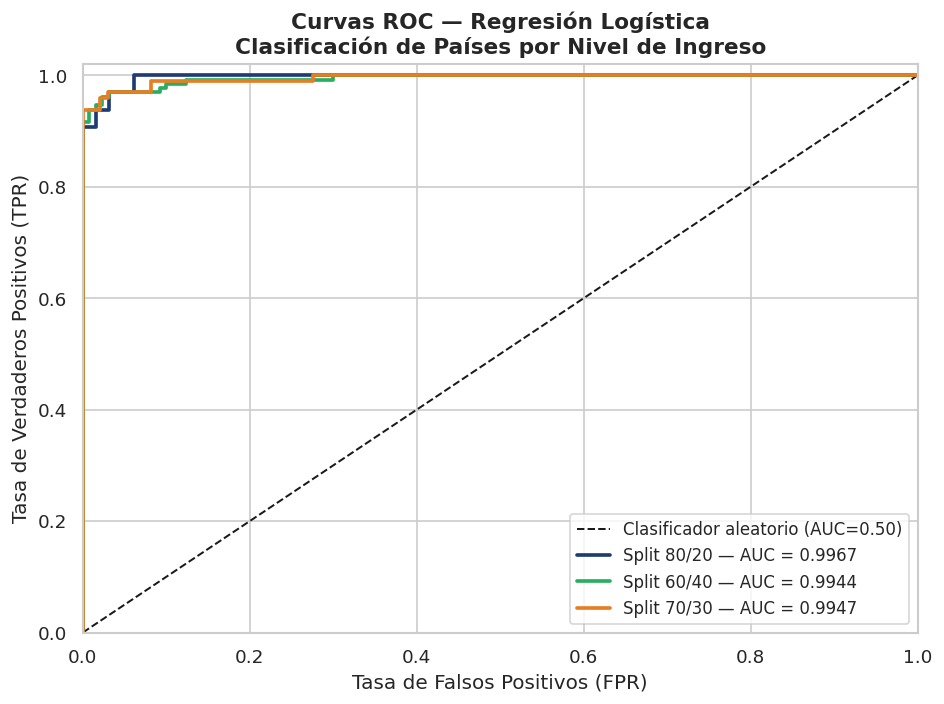

✅ Curvas ROC guardadas en data/graficas/roc_logistica_pib.png


In [11]:
# ── CELDA 7: Curvas ROC comparativas ─────────────────────────────────────────
COLORS = ['#1e3c72', '#27ae60', '#e67e22']

fig, ax = plt.subplots(figsize=(8, 6))
# Referencia: lo que obtendrías si el modelo solo adivinara al azar
ax.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Clasificador aleatorio (AUC=0.50)')

for r, color in zip(resultados, COLORS):
    ax.plot(
        r['fpr'], r['tpr'], color=color, lw=2.2,
        label=f"{r['nombre']} — AUC = {r['roc_auc']:.4f}"
    )

ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12)
ax.set_title('Curvas ROC — Regresión Logística\nClasificación de Países por Nivel de Ingreso', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
plt.tight_layout()

# Guardamos la gráfica en la carpeta del proyecto económico
plt.savefig('../data/graficas/roc_logistica_pib.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Curvas ROC guardadas en data/graficas/roc_logistica_pib.png")

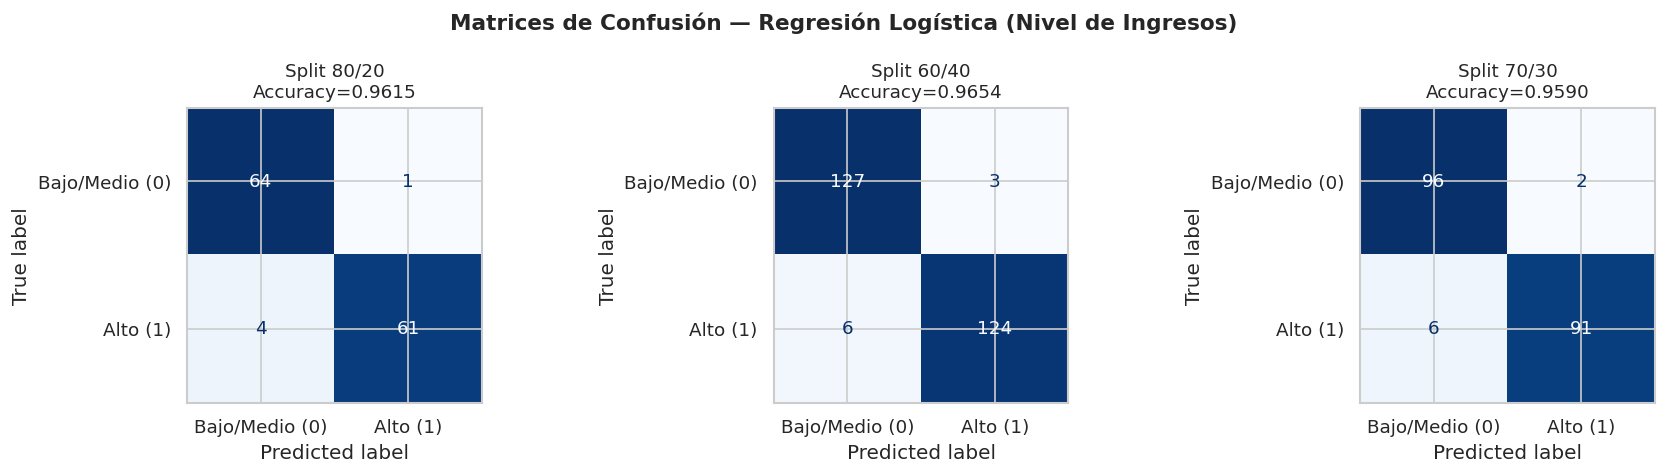

✅ Matrices de confusión guardadas en data/graficas/confusion_logistica_pib.png


In [12]:
# ── CELDA 8: Matrices de Confusión (3 splits) ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Matrices de Confusión — Regresión Logística (Nivel de Ingresos)', fontsize=13, fontweight='bold')

for ax, r in zip(axes, resultados):
    cm   = confusion_matrix(r['y_test'], r['y_pred'])
    # Etiquetas adaptadas: 0 para ingreso bajo/medio, 1 para ingreso alto
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Bajo/Medio (0)', 'Alto (1)'])
    
    # Usamos un mapa de colores que facilite la lectura de la diagonal principal
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f"{r['nombre']}\nAccuracy={r['accuracy']:.4f}", fontsize=11)

plt.tight_layout()
# Guardamos con nombre único para evitar sobrescribir el proyecto de clima
plt.savefig('../data/graficas/confusion_logistica_pib.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Matrices de confusión guardadas en data/graficas/confusion_logistica_pib.png")

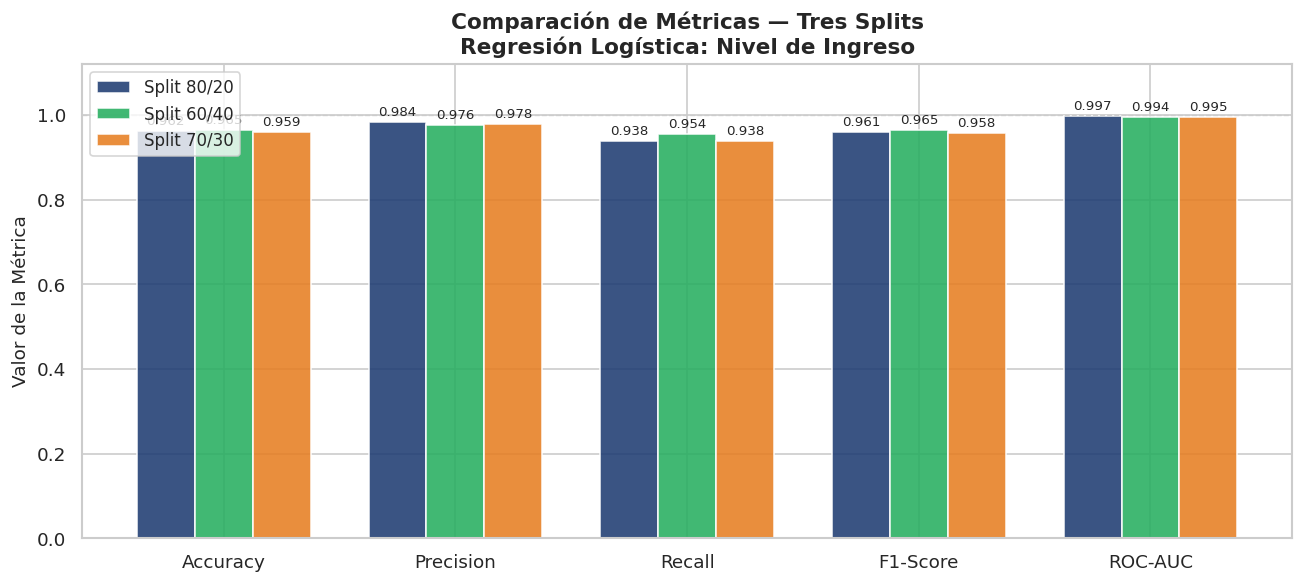

✅ Gráfico de métricas guardado exitosamente en '../data/graficas/metricas_comparativas_logistica_pib.png'


In [13]:
# ── CELDA 9: Gráfico comparativo de métricas ─────────────────────────────────
# Aseguramos los colores por si se reinicia el kernel
COLORS = ['#1e3c72', '#27ae60', '#e67e22']

metricas_nombres = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
etiquetas        = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']

x     = np.arange(len(etiquetas))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 5))
for i, (r, color) in enumerate(zip(resultados, COLORS)):
    vals = [r[m] for m in metricas_nombres]
    bars = ax.bar(x + i * width, vals, width, label=r['nombre'], color=color, alpha=0.88)
    # Añadimos etiquetas de valor sobre cada barra para lectura rápida
    ax.bar_label(bars, fmt='%.3f', padding=2, fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(etiquetas, fontsize=11)
ax.set_ylim([0, 1.12])
ax.set_ylabel('Valor de la Métrica', fontsize=11)
ax.set_title('Comparación de Métricas — Tres Splits\nRegresión Logística: Nivel de Ingreso', fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='upper left')
ax.axhline(y=1.0, color='#ccc', linewidth=0.8, linestyle='--')

plt.tight_layout()
# Guardamos la comparación final
plt.savefig('../data/graficas/metricas_comparativas_logistica_pib.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Gráfico de métricas guardado exitosamente en '../data/graficas/metricas_comparativas_logistica_pib.png'")

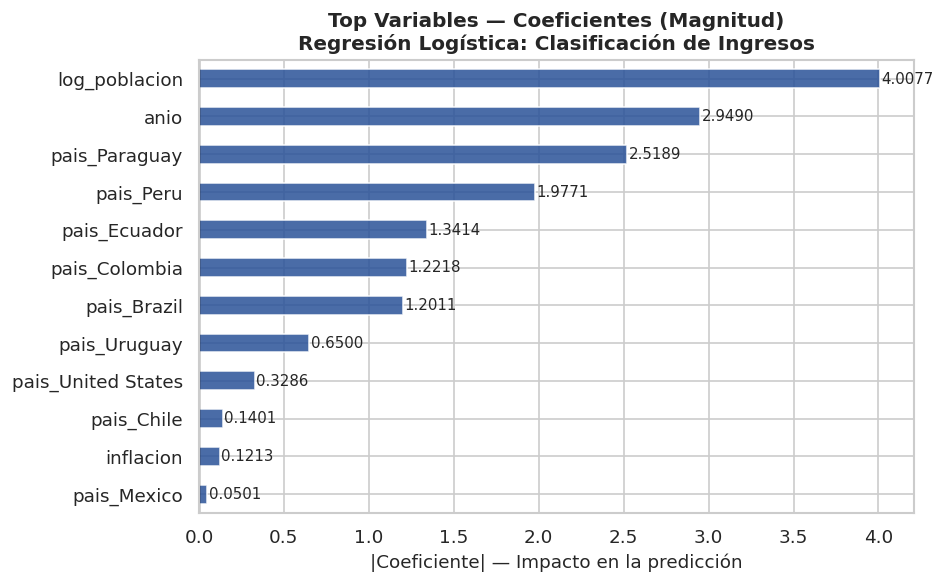

✅ Importancia de coeficientes guardada en data/graficas/coeficientes_logistica_pib.png

🔍 Dirección del impacto (Top 5 variables):
---------------------------------------------
 · log_poblacion   :   4.0077 -> Positivo (Suma probabilidad de Ingreso Alto)
 · anio            :   2.9490 -> Positivo (Suma probabilidad de Ingreso Alto)
 · pais_Ecuador    :  -1.3414 -> Negativo (Resta probabilidad de Ingreso Alto)
 · pais_Peru       :  -1.9771 -> Negativo (Resta probabilidad de Ingreso Alto)
 · pais_Paraguay   :  -2.5189 -> Negativo (Resta probabilidad de Ingreso Alto)


In [15]:
# ── CELDA 10: Importancia de coeficientes (Interpretación Lineal) ────────────
# Tomamos el modelo entrenado con el split 80/20
modelo_ref = resultados[0]['modelo']

# Extraemos los coeficientes y los asociamos a los nombres de las columnas
coefs      = pd.Series(modelo_ref.coef_[0], index=X_scaled.columns)

# Ordenamos por valor absoluto para ver cuáles tienen mayor impacto
coefs_ord  = coefs.abs().sort_values(ascending=True).tail(12)

fig, ax = plt.subplots(figsize=(8, 5))
coefs_ord.plot(kind='barh', ax=ax, color='#2a5298', alpha=0.85)

ax.set_xlabel('|Coeficiente| — Impacto en la predicción', fontsize=11)
ax.set_title('Top Variables — Coeficientes (Magnitud)\nRegresión Logística: Clasificación de Ingresos', fontsize=12, fontweight='bold')
ax.axvline(x=0, color='black', linewidth=0.8)

# Añadimos los valores exactos a las barras
for patch in ax.patches:
    width = patch.get_width()
    ax.text(width + 0.01, patch.get_y() + patch.get_height()/2, 
            f'{width:.4f}', va='center', fontsize=9)

plt.tight_layout()

# Guardamos la gráfica de coeficientes
plt.savefig('../data/graficas/coeficientes_logistica_pib.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Importancia de coeficientes guardada en data/graficas/coeficientes_logistica_pib.png")

# --- ANÁLISIS DE DIRECCIÓN ---
print("\n🔍 Dirección del impacto (Top 5 variables):")
print("-" * 45)
top_5 = coefs.loc[coefs_ord.tail(5).index].sort_values(ascending=False)
for var, val in top_5.items():
    direccion = "Positivo (Suma probabilidad de Ingreso Alto)" if val > 0 else "Negativo (Resta probabilidad de Ingreso Alto)"
    print(f" · {var:<15} : {val:>8.4f} -> {direccion}")

In [16]:
# ── CELDA 11: DataFrame resumen de métricas ───────────────────────────────────
resumen = pd.DataFrame([{
    'Split'          : r['nombre'],
    'N Entrenamiento': r['train_size'],
    'N Prueba'       : r['test_size'],
    'Accuracy'       : round(r['accuracy'],   4),
    'Precision'      : round(r['precision'],  4),
    'Recall'         : round(r['recall'],     4),
    'F1-Score'       : round(r['f1'],         4),
    'ROC-AUC'        : round(r['roc_auc'],    4),
} for r in resultados])

resumen.set_index('Split', inplace=True)

print("=" * 65)
print(f"{'TABLA FINAL DE MÉTRICAS ECONÓMICAS':^65}")
print("=" * 65)

# Presentación visual con gradientes de color
display(resumen.style
    .background_gradient(cmap='Greens', subset=['Accuracy','Precision','Recall','F1-Score','ROC-AUC'])
    .format('{:.4f}', subset=['Accuracy','Precision','Recall','F1-Score','ROC-AUC'])
    .set_caption("Regresión Logística — Clasificación de Nivel de Ingreso (Países)")
)

print("\n📌 Notas finales del modelo:")
print("  · El AUC mide la capacidad de separación entre clases económicas.")
print("  · F1-Score es el balance ideal entre Precision y Recall.")
print("  · La consistencia entre splits valida que el escalado (StandardScaler) fue efectivo.")

               TABLA FINAL DE MÉTRICAS ECONÓMICAS                


,N Entrenamiento,N Prueba,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Split,,,,,,,
Split 80/20,520,130,0.9615,0.9839,0.9385,0.9606,0.9967
Split 60/40,390,260,0.9654,0.9764,0.9538,0.9650,0.9944
Split 70/30,455,195,0.9590,0.9785,0.9381,0.9579,0.9947



📌 Notas finales del modelo:
  · El AUC mide la capacidad de separación entre clases económicas.
  · F1-Score es el balance ideal entre Precision y Recall.
  · La consistencia entre splits valida que el escalado (StandardScaler) fue efectivo.
